In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [41]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [42]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [43]:
def tanh(z):
    return (np.exp(z) - np.exp(-z))/(np.exp(z) + np.exp(-z))

In [44]:
def relu(z):
    return np.maximum(0, z)

In [45]:
def leakyrelu(z, alpha):
    return np.maximum(z * alpha, z)

In [46]:
z = np.array([-5, -1, 0, 1, 5])
print(sigmoid(z))
print(tanh(z))
print(relu(z))
print(leakyrelu(z, 0.01))

[0.00669285 0.26894142 0.5        0.73105858 0.99330715]
[-0.9999092  -0.76159416  0.          0.76159416  0.9999092 ]
[0 0 0 1 5]
[-0.05 -0.01  0.    1.    5.  ]


In [47]:
w1 = np.random.normal(0, 0.1, (2, 4))
w2 = np.random.normal(0, 0.1, (4, 1))
b1 = np.random.normal(0.01, 0.01, (1, 4))
b2 = np.random.normal(0.01, 0.01, (1, 1))

In [48]:
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
X = X.T
y = np.array([0, 1, 1, 0])
y = y.reshape(-1 ,1)

In [49]:
def ggsgonext(y, yh):
    return -np.mean(y * np.log(yh) + (1 - y) * np.log(1 - yh))

In [50]:
def dz2(yhat, y):
    return yhat - y

In [51]:
def dw2(h, d, n):
    return (h.T @ d)/n

In [52]:
def db2(d):
    return np.mean(d, keepdims = True)

In [53]:
def drelu(z):
    return (z > 0).astype(float)

In [54]:
def dlrelu(z):
    return np.where(z > 0, 1, 0.01)

In [55]:
eta = 0.5
for sm in range(10000):
    z1 = X @ w1 + b1
    h1 = leakyrelu(z1, 0.01)
    z2 = h1 @ w2 + b2
    yhat = sigmoid(z2)
    yhat = np.clip(yhat, 1e-8, 1 - 1e-8)
    loss = ggsgonext(y, yhat)
    d2 = dz2(yhat, y)
    dh1 = dz2(yhat, y) @ w2.T
    dz1 = dh1 * dlrelu(z1)
    dw1 = (X.T @ dz1)/len(X)
    dwtwo = dw2(h1, d2, len(X))
    dbtwo = db2(d2)
    db1 = np.mean(dz1, axis=0, keepdims=True)
    w1 = w1 - eta * dw1
    b1 = b1 - eta * db1
    w2 = w2 - eta * dwtwo
    b2 = b2 - eta * dbtwo
    if sm % 1000 == 0:
        print(sm, loss)

0 0.6927347298664066
1000 0.3624876053201251
2000 0.3624873617042646
3000 0.36248733076445055
4000 0.36248725641764207
5000 0.010152822682949824
6000 0.0023998926611441588
7000 0.0013299809684806233
8000 0.0009125927215602589
9000 0.000692229585865143


In [56]:
print("Predictions:", yhat.flatten())
print("Targets:", y.flatten())
print("Hidden activations:", h1)

Predictions: [1.78718284e-03 9.99815333e-01 9.99845846e-01 9.81708602e-05]
Targets: [0 1 1 0]
Hidden activations: [[-2.41653416e-02 -2.35119601e-06 -4.16021420e-06 -2.16502886e-06]
 [ 1.93488275e-06 -2.94660932e-02 -1.49383651e-02  3.66501961e+00]
 [-2.22256549e-07  2.94640049e+00  1.49305498e+00 -1.94548132e-02]
 [ 2.41651386e+00  2.62910094e-05 -3.65510408e-06  1.71975479e+00]]


In [57]:
xr = np.linspace(-0.5, 1.5, 200)
yr = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(xr, yr)

In [58]:
grid = np.column_stack((xx.flatten(), yy.flatten()))

In [59]:
z1 = grid @ w1 + b1   
h1 = leakyrelu(z1, 0.01)    
z2 = h1 @ w2 + b2    
gp = sigmoid(z2)

In [60]:
gp.shape

(40000, 1)

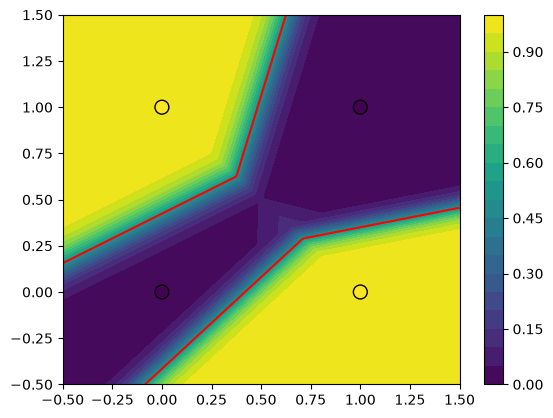

In [61]:
gp = gp.reshape(xx.shape)
fig, ax = plt.subplots()
contour = plt.contourf(xx, yy, gp, levels = 20, cmap = 'viridis')
fig.colorbar(contour)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=100, edgecolors='black', zorder=3)
ax.contour(xx, yy, gp, levels=[0.5], colors='red')

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
model = LogisticRegression(max_iter = 1000, random_state = 33550336)
model.fit(X, y.flatten())
yp = model.predict(X)

print("Predictions:", yp)
print("Targets:", y.flatten())
print("Accuracy:", model.score(X, y.flatten()))

Predictions: [0 0 0 0]
Targets: [0 1 1 0]
Accuracy: 0.5


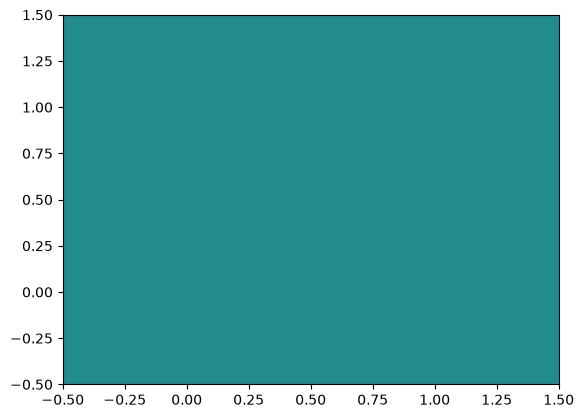

In [64]:
tf = model.predict_proba(grid)
lrp = tf[:, 1]
lrp = lrp.reshape(xx.shape)
fig, ax = plt.subplots()
contour = ax.contourf(xx, yy, lrp, levels=20, cmap='viridis')

In [65]:
def elu(z, alpha):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

In [66]:
def gelu(z):
    return z/2 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z ** 3)))

In [67]:
def swish(z):
    return z * sigmoid(z)

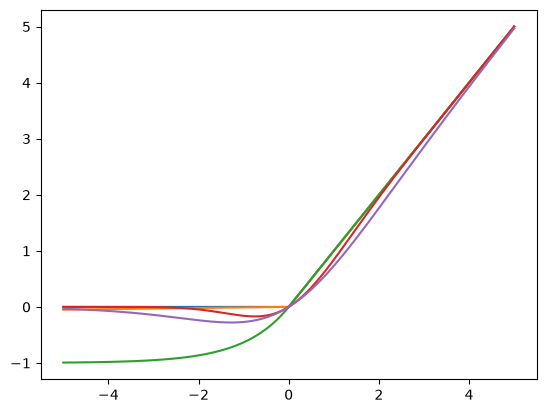

In [68]:
z = np.linspace(-5, 5, 500)
plt.plot(z, relu(z))
plt.plot(z, leakyrelu(z, 0.01))
plt.plot(z, elu(z, 1))
plt.plot(z, gelu(z))
plt.plot(z, swish(z))

In [69]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [70]:
digits = load_digits()
X, y = digits.data, digits.target
X  /= 16

In [71]:
xtr, xte, ytr, yte = train_test_split(X, y, test_size = 0.2, random_state = 33550336, stratify = y)

In [101]:
w1 = np.random.normal(0, np.sqrt(2/64), size = (64, 32))
w2 = np.random.normal(0, np.sqrt(2/32), size = (32, 16))
w3 = np.random.normal(0, np.sqrt(2/16), size = (16, 10))
b1 = np.zeros((1, 32))
b2 = np.zeros((1, 16))
b3 = np.zeros((1, 10))

In [75]:
def softmax(z):
    shifted = z - np.max(z, axis = 1, keepdims = True)
    expz = np.exp(shifted)
    rsum = np.sum(expz, axis = 1, keepdims = True)
    return expz/rsum

In [76]:
z1 = xtr @ w1 + b1
h1 = relu(z1)
z2 = h1 @ w2 + b2
h2 = relu(z2)
z3 = h2 @ w3 + b3
yhat = softmax(z3)

In [99]:
onehot = np.zeros((len(ytr), 10))
onehot[np.arange(len(ytr)), ytr] = 1

In [78]:
onehot.shape

(1437, 10)

In [96]:
def ce(yhat, onehot):
    yhat = yhat.clip(1e-12, 1.0)    
    return -np.mean(np.sum(onehot * np.log(yhat), axis = 1))

In [83]:
def dz3(y, yhat):
    return yhat - y


In [87]:
def dw(h, d, n):
    return (h.T @ d)/n

In [88]:
def db(d):
    return np.mean(d, axis = 0)

In [89]:
def dh(d, w):
    return d @ w.T

In [90]:
def dz(d, z):
    return d * drelu(z)

In [98]:
print(onehot.shape)
print(onehot[:5])
print(np.sum(onehot, axis=1)[:10])

(1437, 10)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [102]:
eta = 0.1
for _ in range(1000):
    z1 = xtr @ w1 + b1
    h1 = relu(z1)
    z2 = h1 @ w2 + b2
    h2 = relu(z2)
    z3 = h2 @ w3 + b3
    yhat = softmax(z3)
    gz3 = dz3(onehot, yhat)
    gw3 = dw(h2, gz3, len(xtr))
    gb3 = db(gz3)
    gh2 = dh(gz3, w3)
    gz2 = dz(gh2, z2)
    gw2 = dw(h1, gz2, len(xtr))
    gb2 = db(gz2)
    gh1 = dh(gz2, w2)
    gz1 = dz(gh1, z1)
    gw1 = dw(xtr, gz1, len(xtr))
    gb1 = db(gz1)
    w3 -= eta * gw3
    w2 -= eta * gw2
    w1 -= eta * gw1
    b3 -= eta * gb3
    b2 -= eta * gb2
    b1 -= eta * gb1
    if _ % 100 == 0:
        print( ce(yhat, onehot))

2.4558074120630797
0.701717965446903
0.2708606298696152
0.16245046193449167
0.11819752784247523
0.0932431154762893
0.07670771482989198
0.0646517269336509
0.05524124432639869
0.047711943097536305


In [104]:
z1 = xte @ w1 + b1
h1 = relu(z1)
z2 = h1 @ w2 + b2
h2 = relu(z2)
z3 = h2 @ w3 + b3
yhat = softmax(z3)

In [105]:
predictions = np.argmax(yhat, axis=1)

In [106]:
np.mean(predictions == yte)

np.float64(0.975)